# F6 — Receivables, collateral and available borrowing

A business can sometimes borrow against unpaid customer invoices. The lender may exclude invoices that are old, disputed or conditional, and may limit how much depends on a single customer. The total invoiced amount therefore differs from the amount available to borrow.

Read F3 and F4 first. Our business rents computer time and sells it to customers. It owns no GPUs. An unpaid amount that a customer owes is a **receivable**. **Collateral** is property or a claim pledged to support a loan. Here it consists of eligible customer receivables, subject to the lender having the required rights over them.

All rules here are **hypothetical**. We assume the lender already has the required rights over the invoices. This calculator does not decide whether those rights are legally valid.

An invoice counts only if payment is owed without an unmet condition, nobody disputes it, and it is no more than 60 days old. A promise to buy future services is not enough.

F4 limits borrowing by what cash can repay. F6 adds a separate limit based on qualifying invoices. A proposed loan must satisfy both limits. They are not separate amounts of financing that can be added together.

In [1]:
# Install the teaching package from GitHub when running in Google Colab.
# Local Jupyter uses the repository's existing environment.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "liquid-compute[colab] @ git+https://github.com/zach189/education.git@main",
        ]
    )
    from google.colab import output

    output.enable_custom_widget_manager()

In [2]:
from dataclasses import replace

from IPython.display import display

from liquid_compute.collateral import Receivable, calculate_receivables_borrowing_base
from liquid_compute.education import (
    explore_finance_series,
    plot_finance_series,
    show_finance_table,
)

invoices = (
    Receivable("A", 100_000, 30),
    Receivable("B", 80_000, 30),
    Receivable("C", 20_000, 30),
)
terms = dict(
    maximum_age_days=60,
    concentration_fraction=0.40,
    advance_fraction=0.80,
    reserve_usd=10_000,
    facility_limit_usd=150_000,
    debt_usd=100_000,
)
print("Eligible invoice ages include day 60; day 61 fails this illustrative cutoff.")

Eligible invoice ages include day 60; day 61 fails this illustrative cutoff.


## Apply eligibility and customer concentration limits

Three customers owe USD 100,000, USD 80,000 and USD 20,000. All three invoices qualify, giving a USD 200,000 pool.

A customer concentration limit reduces reliance on a single payer. Our rule counts at most 40% of that original pool per customer: **USD 80,000 each**. We calculate that cap once, before reducing any customer's amount.

So the first customer's USD 100,000 counts as USD 80,000. The others count in full. The adjusted pool is USD 180,000.

The lender allows borrowing of 80% of this adjusted pool, then takes off a USD 10,000 safety deduction, called a **reserve** here. This deduction reduces the loan limit. It is not money placed in a separate savings account, like the cash reserve in F9.

In [3]:
eligible_usd = 100_000 + 80_000 + 20_000
customer_cap_usd = 0.40 * eligible_usd
adjusted_usd = (
    min(100_000, customer_cap_usd)
    + min(80_000, customer_cap_usd)
    + min(20_000, customer_cap_usd)
)
base_usd = max(0, adjusted_usd * 0.80 - 10_000)
available_usd = max(0, min(150_000, base_usd) - 100_000)
show_finance_table(
    ["Direct step", "USD"],
    [
        ["Eligible", eligible_usd],
        ["After concentration", adjusted_usd],
        ["Borrowing base", base_usd],
        ["Additional availability", available_usd],
    ],
)

| Direct step | USD |
| --- | --- |
| Eligible | 200,000.00 |
| After concentration | 180,000.00 |
| Borrowing base | 134,000.00 |
| Additional availability | 34,000.00 |

Eighty percent of USD 180,000 is USD 144,000. Subtracting USD 10,000 gives a **USD 134,000 borrowing base**: the loan limit supported by these invoices under our rules.

We already owe USD 100,000, leaving **USD 34,000 available**. The separate USD 150,000 maximum loan agreement does not limit us yet.

The table shows which invoices count and why. We combine all invoices from the same customer before applying the cap. Splitting one bill into several smaller bills does not create new customers.

“Available” means we are allowed to borrow that amount. It does not mean the money has arrived. No new loan, interest charge or customer payment happens automatically.

In [4]:
baseline = calculate_receivables_borrowing_base(invoices, **terms)
show_finance_table(
    ["Customer", "Face amount (USD)", "Eligible before cap (USD)", "Reason"],
    [
        [r.invoice.customer_id, r.invoice.amount_usd, r.eligible_usd, r.reason]
        for r in baseline.invoices
    ],
)
show_finance_table(
    ["Customer", "Concentration deduction (USD)"],
    list(baseline.customer_deductions_usd),
)

| Customer | Face amount (USD) | Eligible before cap (USD) | Reason |
| --- | --- | --- | --- |
| A | 100,000.00 | 100,000.00 | eligible |
| B | 80,000.00 | 80,000.00 | eligible |
| C | 20,000.00 | 20,000.00 | eligible |

| Customer | Concentration deduction (USD) |
| --- | --- |
| A | 20,000.00 |
| B | 0.00 |
| C | 0.00 |

All the starting invoices meet the age, payment and dispute rules. Only USD 20,000 from the largest customer is removed by the customer cap. We do not remove it twice.

Read the chart as steps in today's calculation, not as money moving over time. The controls change the age limit, lending percentage and safety deduction independently of other examples.

If debt is above the allowed limit, the excess is called an **overadvance**. We show it separately. Saying “nothing more is available” would hide how far over the limit we are.

| Case | Eligible (USD) | Adjusted (USD) | Base (USD) | Available (USD) | Overadvance (USD) |
| --- | --- | --- | --- | --- | --- |
| Baseline | 200,000.00 | 180,000.00 | 134,000.00 | 34,000.00 | 0.00 |

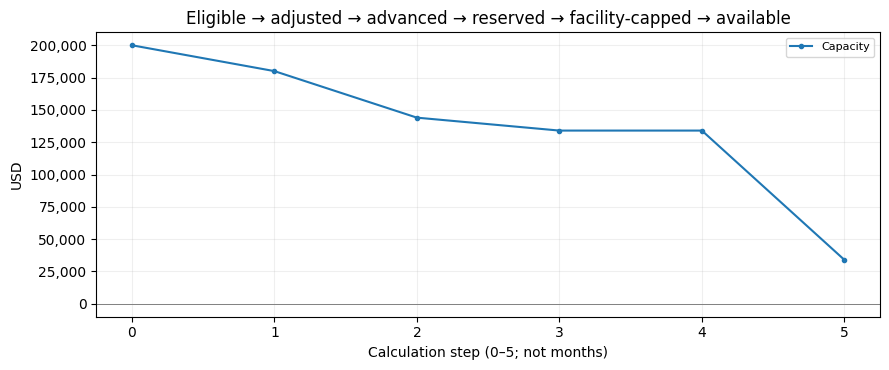

In [5]:
def summary(scenarios):
    show_finance_table(
        [
            "Case",
            "Eligible (USD)",
            "Adjusted (USD)",
            "Base (USD)",
            "Available (USD)",
            "Overadvance (USD)",
        ],
        [
            [
                name,
                r.eligible_usd,
                r.adjusted_eligible_usd,
                r.borrowing_base_usd,
                r.availability_usd,
                r.overadvance_usd,
            ]
            for name, r in scenarios.items()
        ],
    )


summary({"Baseline": baseline})
display(
    plot_finance_series(
        {
            "Capacity": [
                eligible_usd,
                adjusted_usd,
                baseline.gross_advance_usd,
                baseline.borrowing_base_usd,
                min(baseline.facility_limit_usd, baseline.borrowing_base_usd),
                baseline.availability_usd,
            ]
        },
        title="Eligible → adjusted → advanced → reserved → facility-capped → available",
        xlabel="Calculation step (0–5; not months)",
    )
)


def collateral_explorer(values, pool=invoices, source=terms.copy()):
    from liquid_compute.collateral import calculate_receivables_borrowing_base

    current = source | dict(
        maximum_age_days=values["Age limit (days)"],
        advance_fraction=values["Advance fraction"],
        reserve_usd=values["Reserve (USD)"],
    )
    result = calculate_receivables_borrowing_base(pool, **current)
    return {
        "Capacity steps": [
            result.eligible_usd,
            result.adjusted_eligible_usd,
            result.gross_advance_usd,
            result.borrowing_base_usd,
            min(result.borrowing_base_usd, result.facility_limit_usd),
            result.availability_usd,
        ]
    }


explore_finance_series(
    {"Age limit (days)": 60, "Advance fraction": 0.80, "Reserve (USD)": 10_000.0},
    collateral_explorer,
    title="Eligible → adjusted → advanced → reserved → capped → available",
    xlabel="Calculation step (0–5; not months)",
);

We can borrow another **USD 34,000**, and we are not over the limit. This does not predict when customers will pay.

## Experiment 1 — An invoice exceeds the age limit

Make customer B's USD 80,000 invoice 61 days old. The customer still owes the money, but the invoice no longer counts under our 60-day rule. Being old does not by itself prove the customer will never pay.

Removing it also shrinks the pool used to set every customer's cap.

In [6]:
aged_invoices = (invoices[0], replace(invoices[1], age_days=61), invoices[2])
aged = calculate_receivables_borrowing_base(aged_invoices, **terms)
summary({"Baseline": baseline, "B aged to 61 days": aged})

| Case | Eligible (USD) | Adjusted (USD) | Base (USD) | Available (USD) | Overadvance (USD) |
| --- | --- | --- | --- | --- | --- |
| Baseline | 200,000.00 | 180,000.00 | 134,000.00 | 34,000.00 | 0.00 |
| B aged to 61 days | 120,000.00 | 68,000.00 | 44,400.00 | 0.00 | 55,600.00 |

The qualifying pool falls to USD 120,000. Each customer can now count for at most **USD 48,000**, which is 40% of that smaller pool.

Customer A counts for USD 48,000 and C for USD 20,000. Eighty percent of their USD 68,000 total, less the USD 10,000 deduction, gives a **USD 44,400 limit**.

We still owe USD 100,000, so we are **USD 55,600 over the limit**. The calculator reports a problem. It does not assume the loan has been repaid or that an invoice has been lost.

## Experiment 2 — All invoices belong to one customer

Return to USD 200,000 of qualifying invoices, but put them all with one customer. Lots of invoices from the same customer do not spread the risk.

In [7]:
concentrated = calculate_receivables_borrowing_base(
    (Receivable("A", 200_000, 30),), **terms
)
summary({"Three customers": baseline, "One customer": concentrated})

| Case | Eligible (USD) | Adjusted (USD) | Base (USD) | Available (USD) | Overadvance (USD) |
| --- | --- | --- | --- | --- | --- |
| Three customers | 200,000.00 | 180,000.00 | 134,000.00 | 34,000.00 | 0.00 |
| One customer | 200,000.00 | 80,000.00 | 54,000.00 | 0.00 | 46,000.00 |

Only USD 80,000 counts after the customer cap. The borrowing base is **USD 54,000**: 80% of USD 80,000, less USD 10,000.

With USD 100,000 already owed, the excess is **USD 46,000**. The total invoices have not changed. The lender counts less because everything depends on one payer.

## Experiment 3 — Invoice growth meets the facility limit

Multiply each original invoice by ten. Keep the same customer shares, USD 10,000 deduction, USD 150,000 agreement limit and USD 100,000 existing debt.

In [8]:
larger_pool = tuple(replace(r, amount_usd=10 * r.amount_usd) for r in invoices)
large = calculate_receivables_borrowing_base(larger_pool, **terms)
summary({"Original pool": baseline, "Ten-times pool": large})

| Case | Eligible (USD) | Adjusted (USD) | Base (USD) | Available (USD) | Overadvance (USD) |
| --- | --- | --- | --- | --- | --- |
| Original pool | 200,000.00 | 180,000.00 | 134,000.00 | 34,000.00 | 0.00 |
| Ten-times pool | 2,000,000.00 | 1,800,000.00 | 1,430,000.00 | 50,000.00 | 0.00 |

The invoices now support more than USD 150,000 under the borrowing-base rule. But the agreement still permits only **USD 150,000 of total debt**.

After subtracting the USD 100,000 already borrowed, only **USD 50,000 more** is available. More invoices do not automatically enlarge the loan agreement.

Keep three questions separate: F3 asks what customers owe and when they pay. F4 asks what cash can repay. F6 asks what today's invoices and loan rules allow. None of these turns a conditional customer promise into money already owed, or gives a reseller ownership of hardware.

In [9]:
summary(
    {
        "Baseline": baseline,
        "Aged B": aged,
        "Concentrated": concentrated,
        "Facility capped": large,
    }
)

| Case | Eligible (USD) | Adjusted (USD) | Base (USD) | Available (USD) | Overadvance (USD) |
| --- | --- | --- | --- | --- | --- |
| Baseline | 200,000.00 | 180,000.00 | 134,000.00 | 34,000.00 | 0.00 |
| Aged B | 120,000.00 | 68,000.00 | 44,400.00 | 0.00 | 55,600.00 |
| Concentrated | 200,000.00 | 80,000.00 | 54,000.00 | 0.00 | 46,000.00 |
| Facility capped | 2,000,000.00 | 1,800,000.00 | 1,430,000.00 | 50,000.00 | 0.00 |

## Next — What if the customer leaves before the loan ends?

Continue to **F7: Renewal and maturity mismatch**.

The [OCC's asset-based lending handbook](https://www.occ.treas.gov/publications-and-resources/publications/comptrollers-handbook/files/asset-based-lending/pub-ch-asset-based-lending.pdf), printed pages 16–18 and 21, discusses invoice age, customer concentration and reserves. Our 60-day and 40% rules are examples, not rules every lender uses.

We leave legal checks and extra collection costs out. We also do not remove a customer's other invoices just because one gets too old. A real loan could have those additional rules.